# BÁO CÁO GIỮA KỲ - NHẬP MÔN XỬ LÝ NGÔN NGỮ TỰ NHIÊN
## Bài toán: Aspect-Based Sentiment Analysis (ABSA)
### Phân tích Cảm xúc Theo Khía cạnh trên Tập dữ liệu MAMS

---
**Sinh viên 1:** [Đặng Kim Anh]  
**MSSV:** [52300090]  
**Sinh viên 2:** [Đậu Phương Dung]  
**MSSV:** [52300100]  
**Sinh viên 3:** [Trần Ngọc Hải My]  
**MSSV:** [52300128]  

---

## 1. Giới thiệu bài toán

### 1.1 Định nghĩa bài toán

Bài toán **Aspect-Based Sentiment Analysis (ABSA)** yêu cầu:

- **Input:** Một câu đánh giá nhà hàng tiếng Anh kèm theo một **aspect term** cụ thể
- **Output:**
  - **Sentiment Polarity:** Cảm xúc của người viết đối với aspect term đó (`positive`, `negative`, `neutral`)

### 1.2 Tập dữ liệu: MAMS (Multi-Aspect Multi-Sentiment)

**MAMS** là tập dữ liệu ABSA được công bố tại **EMNLP 2019**, với đặc điểm nổi bật là **mỗi câu đều chứa ít nhất hai aspect terms có nhãn cảm xúc khác nhau**, giúp loại bỏ sự thiên lệch trong dữ liệu.

> Li, X., Bing, L., Zhang, W., & Lam, W. (2019). *Exploiting BERT for End-to-End Aspect-based Sentiment Analysis*. EMNLP 2019 Workshop.

**Định dạng:** XML — mỗi `<sentence>` chứa `<aspectTerms>` với thuộc tính `term` và `polarity`.

**Nhãn sentiment:** `positive`, `negative`, `neutral`

**Thống kê tập dữ liệu:**

| Tập | Số câu | Số mẫu (aspect-level) |
|-----|--------|----------------------|
| Train | 4,297 | 11,186 |
| Val   | 500   | 1,332  |
| Test  | 500   | 1,336  |

**Nguồn:** [`siat-nlp/MAMS-for-ABSA`](https://github.com/siat-nlp/MAMS-for-ABSA) (GitHub)

### 1.3 Hai hướng tiếp cận

| Hướng | Mô hình | Đặc điểm |
|-------|---------|-----------|
| **Build from scratch** | BiLSTM + Embedding | Train từ đầu, kiểm soát hoàn toàn kiến trúc |
| **Pretrained model** | BERT (bert-base-uncased) | Fine-tune, tận dụng tri thức từ pre-training |


In [7]:
# ============================================================
# Cài đặt các thư viện cần thiết
# ============================================================
!pip install transformers==4.38.2 datasets torch torchvision torchaudio --quiet
!pip install scikit-learn pandas numpy matplotlib seaborn wordcloud tqdm --quiet
!pip install accelerate --quiet

print(" Cài đặt hoàn tất!")


 Cài đặt hoàn tất!


---
## PHẦN 1: CÀI ĐẶT THƯ VIỆN VÀ IMPORT

> **Môi trường:** Google Colab (GPU T4)
> Tất cả thư viện NLP và Deep Learning cần thiết được cài đặt trong bước này.


In [8]:
# ============================================================
# Import tất cả thư viện cần dùng
# ============================================================
import os, json, time, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR

# HuggingFace Transformers
from transformers import (
    BertTokenizer,
    BertModel,
    get_linear_schedule_with_warmup
)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Tqdm progress bar
from tqdm.auto import tqdm

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device đang sử dụng: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Seed để tái lặp kết quả
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
print(f"\nRandom seed đã đặt: {SEED}")


 Device đang sử dụng: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB

Random seed đã đặt: 42


---
## PHẦN 2: TẢI VÀ KHÁM PHÁ DỮ LIỆU MAMS

**MAMS (Multi-Aspect Multi-Sentiment)** cung cấp dữ liệu dưới dạng XML với cấu trúc:
```xml
<sentences>
  <sentence id="...">
    <text>Great food but the service was very slow.</text>
    <aspectTerms>
      <aspectTerm term="food"    polarity="positive" from="6"  to="10"/>
      <aspectTerm term="service" polarity="negative" from="19" to="26"/>
    </aspectTerms>
  </sentence>
</sentences>
```

**Đặc điểm nổi bật của MAMS:**
- Mỗi câu chứa **ít nhất 2 aspect terms** với nhãn sentiment **khác nhau** → loại bỏ thiên lệch one-label-per-sentence
- Dữ liệu đã được **chia sẵn** thành `train.xml` / `val.xml` / `test.xml`
- Chỉ có **3 nhãn** sentiment: `positive`, `negative`, `neutral` (không có `conflict`)

**Nguồn tải:** Tải trực tiếp từ GitHub repository [`siat-nlp/MAMS-for-ABSA`](https://github.com/siat-nlp/MAMS-for-ABSA) bằng `wget`.


In [9]:
# ============================================================
# Tải và xử lý dữ liệu MAMS từ Google Drive (Bản chống lỗi)
# ============================================================
import os
import xml.etree.ElementTree as ET
import pandas as pd

# 1. KẾT NỐI VỚI GOOGLE DRIVE
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

# ĐƯỜNG DẪN TỚI THƯ MỤC TRÊN DRIVE
DATA_DIR = "/content/drive/MyDrive/NLP_MAMS"

# --- Hàm parse MAMS XML ---
def parse_mams_xml(filepath):
    try:
        tree = ET.parse(filepath)
        root = tree.getroot()
    except Exception as e:
        print(f"Lỗi đọc file {filepath}: File có thể bị hỏng hoặc tải nhầm định dạng HTML. ({e})")
        return []

    records = []
    for sentence in root.findall("sentence"):
        text_el = sentence.find("text")
        if text_el is None or not text_el.text:
            continue
        text = text_el.text.strip()

        # Hỗ trợ đọc cả MAMS-ATSA (aspectTerms) và MAMS-ACSA (aspectCategories)
        aspects = sentence.find("aspectTerms")
        categories = sentence.find("aspectCategories")

        # Xử lý nếu là MAMS-ATSA
        if aspects is not None:
            for at in aspects.findall("aspectTerm"):
                term     = (at.get("term") or "").strip().lower()
                polarity = (at.get("polarity") or "").strip().lower()
                if term and polarity in {"positive", "negative", "neutral"}:
                    records.append({"text": text, "aspect_term": term, "sentiment": polarity})

        # Xử lý nếu là MAMS-ACSA
        if categories is not None:
            for ac in categories.findall("aspectCategory"):
                term     = (ac.get("category") or "").strip().lower()
                polarity = (ac.get("polarity") or "").strip().lower()
                if term and polarity in {"positive", "negative", "neutral"}:
                    records.append({"text": text, "aspect_term": term, "sentiment": polarity})

    return records

# --- Đọc cả 3 tập ---
TRAIN_XML = os.path.join(DATA_DIR, "train.xml")
VAL_XML   = os.path.join(DATA_DIR, "val.xml")
TEST_XML  = os.path.join(DATA_DIR, "test.xml")

if not os.path.exists(TRAIN_XML):
    print(f"KHÔNG TÌM THẤY FILE TẠI: {TRAIN_XML}")
else:
    # Bắt buộc tạo DataFrame với các cột chuẩn, dù dữ liệu có rỗng
    cols = ["text", "aspect_term", "sentiment"]
    df_train_raw = pd.DataFrame(parse_mams_xml(TRAIN_XML), columns=cols)
    df_val_raw   = pd.DataFrame(parse_mams_xml(VAL_XML), columns=cols)
    df_test_raw  = pd.DataFrame(parse_mams_xml(TEST_XML), columns=cols)

    # Thêm cột độ dài câu (chỉ tính độ dài nếu DataFrame có dữ liệu để tránh lỗi KeyError)
    for df in [df_train_raw, df_val_raw, df_test_raw]:
        if not df.empty:
            df["n_tokens"] = df["text"].apply(lambda x: len(str(x).split()))
        else:
            df["n_tokens"] = [] # Gán mảng rỗng nếu không có dữ liệu

    print("\nQuá trình Parse dữ liệu hoàn tất!")
    print(f"   Train : {len(df_train_raw):,} mẫu")
    print(f"   Val   : {len(df_val_raw):,} mẫu")
    print(f"   Test  : {len(df_test_raw):,} mẫu")

    if len(df_train_raw) > 0:
        print(f"\nVí dụ 5 dòng đầu (train):")
        display(df_train_raw.head(5))
    else:
        print("\nCẢNH BÁO: Tập Train có 0 dòng dữ liệu. Vui lòng mở thử file train.xml trên máy tính xem bên trong có dữ liệu thực sự hay chỉ là code trang web HTML.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Quá trình Parse dữ liệu hoàn tất!
   Train : 11,186 mẫu
   Val   : 1,332 mẫu
   Test  : 1,336 mẫu

Ví dụ 5 dòng đầu (train):


,text,aspect_term,sentiment,n_tokens
0,The decor is not special at all but their food...,decor,negative,17
1,The decor is not special at all but their food...,food,positive,17
2,The decor is not special at all but their food...,prices,positive,17
3,"when tables opened up, the manager sat another...",tables,neutral,11
4,"when tables opened up, the manager sat another...",manager,negative,11


---
## PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU & TOKENIZATION

**Bài toán:** Aspect-Term Sentiment Classification (ATSC)  
- **Input:** câu văn bản + aspect term (từ/cụm từ cụ thể)  
- **Output:** polarity của aspect term đó trong câu (`positive` / `negative` / `neutral`)

**Nguồn dữ liệu:**  
| File | Mô tả | Số mẫu |
|------|-------|--------|
| `train.xml` | Tập huấn luyện | ~11,186 |
| `val.xml`   | Tập validation  | ~1,332  |
| `test.xml`  | Tập kiểm tra   | ~1,336  |

> MAMS đã cung cấp sẵn split train/val/test → **không cần chia thêm**.  
> Đây là điểm khác biệt quan trọng so với SemEval 2014.

**Không có nhãn `conflict`** → Bài toán phân loại **3 lớp** (`positive`, `negative`, `neutral`).


In [10]:
# ============================================================
# 3.1 Kiểm tra và thống kê tập Train sau khi parse
# ============================================================
df_filtered = df_train_raw.copy().reset_index(drop=True)

print("=" * 55)
print("THỐNG KÊ TẬP TRAIN — MAMS-ATSC")
print("=" * 55)
print(f"  Tổng số mẫu (aspect-level) : {len(df_filtered):,}")
print(f"  Số câu gốc (unique)        : {df_filtered['text'].nunique():,}")
print(f"  Độ dài câu TB              : {df_filtered['n_tokens'].mean():.1f} token")
print(f"  Độ dài câu min / max       : {df_filtered['n_tokens'].min()} / {df_filtered['n_tokens'].max()} token")
print(f"\nPhân phối Sentiment (Train):\n{df_filtered['sentiment'].value_counts()}")
print(f"\nTop-20 Aspect Terms (Train):\n{df_filtered['aspect_term'].value_counts().head(20)}")

# Kiểm tra không có nhãn ngoài 3 lớp
assert set(df_filtered["sentiment"].unique()).issubset({"positive", "negative", "neutral"}), \
    "Có nhãn ngoài kỳ vọng!"
print("\n✅ Dữ liệu hợp lệ — đúng 3 nhãn: positive / negative / neutral")
display(df_filtered.head(8))


THỐNG KÊ TẬP TRAIN — MAMS-ATSC
  Tổng số mẫu (aspect-level) : 11,186
  Số câu gốc (unique)        : 4,297
  Độ dài câu TB              : 24.2 token
  Độ dài câu min / max       : 4 / 67 token

Phân phối Sentiment (Train):
sentiment
neutral     5042
positive    3380
negative    2764
Name: count, dtype: int64

Top-20 Aspect Terms (Train):
aspect_term
food           739
menu           416
waiter         412
service        411
dinner         316
bar            307
waitress       240
drinks         218
table          163
meal           146
place          127
lunch          117
appetizers     113
drink          113
dessert        113
staff          112
wait           110
price          108
manager        104
reservation    103
Name: count, dtype: int64

✅ Dữ liệu hợp lệ — đúng 3 nhãn: positive / negative / neutral


,text,aspect_term,sentiment,n_tokens
0,The decor is not special at all but their food...,decor,negative,17
1,The decor is not special at all but their food...,food,positive,17
2,The decor is not special at all but their food...,prices,positive,17
3,"when tables opened up, the manager sat another...",tables,neutral,11
4,"when tables opened up, the manager sat another...",manager,negative,11
5,Though the menu includes some unorthodox offer...,menu,neutral,26
6,Though the menu includes some unorthodox offer...,peanut butter roll,negative,26
7,Though the menu includes some unorthodox offer...,classics,positive,26


In [11]:
# ============================================================
# 3.2 Label Encoding — nhãn Sentiment (3 lớp: ATSC)
# ============================================================
le_sentiment = LabelEncoder()

# Fit trên TẤT CẢ nhãn để đảm bảo 3 lớp đều xuất hiện
all_labels = (
    df_train_raw["sentiment"].tolist()
    + df_val_raw["sentiment"].tolist()
    + df_test_raw["sentiment"].tolist()
)
le_sentiment.fit(all_labels)
NUM_SENTIMENTS = len(le_sentiment.classes_)
print("Các nhãn Sentiment:", list(le_sentiment.classes_))
print(f"Số lớp phân loại  : {NUM_SENTIMENTS}")

# Gán id cho từng tập
for df in [df_train_raw, df_val_raw, df_test_raw]:
    df["sentiment_id"] = le_sentiment.transform(df["sentiment"])

# ============================================================
# 3.3 Sử dụng split có sẵn của MAMS (không cần chia thêm)
# ============================================================
df_train = df_train_raw.reset_index(drop=True)
df_val   = df_val_raw.reset_index(drop=True)
df_test  = df_test_raw.reset_index(drop=True)

print(f"\nKích thước tập dữ liệu (MAMS pre-split):")
total = len(df_train) + len(df_val) + len(df_test)
print(f"  Train : {len(df_train):,}  ({len(df_train)/total*100:.1f}%)")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/total*100:.1f}%)")
print(f"  Test  : {len(df_test):,}   ({len(df_test)/total*100:.1f}%)")

# Kiểm tra phân phối sentiment trong mỗi tập
print()
for name, df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    dist = df["sentiment"].value_counts().to_dict()
    print(f"  {name} → {dist}")


Các nhãn Sentiment: [np.str_('negative'), np.str_('neutral'), np.str_('positive')]
Số lớp phân loại  : 3

Kích thước tập dữ liệu (MAMS pre-split):
  Train : 11,186  (80.7%)
  Val   : 1,332   (9.6%)
  Test  : 1,336   (9.6%)

  Train → {'neutral': 5042, 'positive': 3380, 'negative': 2764}
  Val → {'neutral': 604, 'positive': 403, 'negative': 325}
  Test → {'neutral': 607, 'positive': 400, 'negative': 329}


---
## PHẦN 4: PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)

Phân tích phân phối nhãn, aspect terms phổ biến, độ dài câu và mối quan hệ giữa aspect và sentiment trên **tập Train của MAMS**.


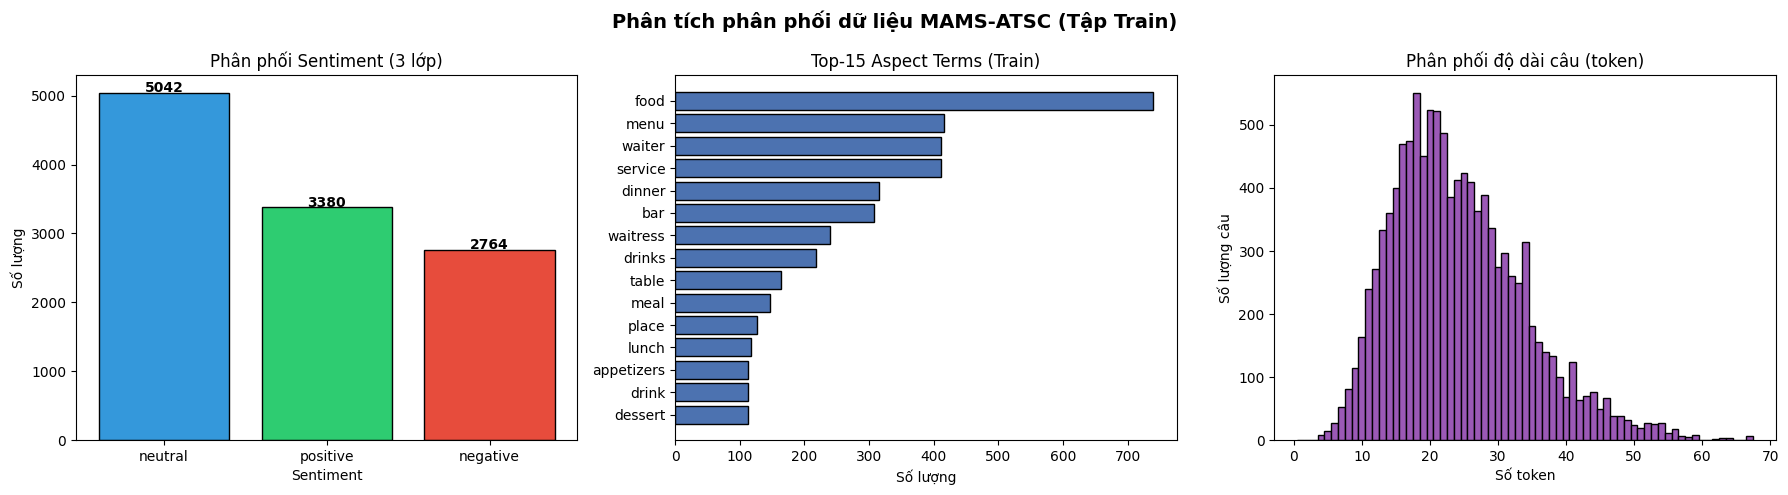

Biểu đồ phân phối đã lưu: eda_distribution.png


In [12]:
# ============================================================
# 4.1 Phân phối Sentiment, Top Aspect Terms, Độ dài câu
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Phân tích phân phối dữ liệu MAMS-ATSC (Tập Train)",
             fontsize=14, fontweight="bold")

# --- Subplot 1: Sentiment distribution (3 nhãn của MAMS) ---
sent_counts = df_filtered["sentiment"].value_counts()
colors_sent = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#3498db"}
bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=[colors_sent.get(s, "gray") for s in sent_counts.index],
                   edgecolor="black")
axes[0].set_title("Phân phối Sentiment (3 lớp)", fontsize=12)
axes[0].set_xlabel("Sentiment"); axes[0].set_ylabel("Số lượng")
for bar, v in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 5, str(v),
                 ha="center", fontweight="bold")

# --- Subplot 2: Top-15 Aspect Terms ---
top_asp = df_filtered["aspect_term"].value_counts().head(15)
axes[1].barh(top_asp.index[::-1], top_asp.values[::-1],
             color="#4C72B0", edgecolor="black")
axes[1].set_title("Top-15 Aspect Terms (Train)", fontsize=12)
axes[1].set_xlabel("Số lượng")

# --- Subplot 3: Token length distribution ---
max_tok = min(df_filtered["n_tokens"].max() + 2, 70)
axes[2].hist(df_filtered["n_tokens"], bins=range(1, max_tok),
             color="#9B59B6", edgecolor="black", align="left")
axes[2].set_title("Phân phối độ dài câu (token)", fontsize=12)
axes[2].set_xlabel("Số token"); axes[2].set_ylabel("Số lượng câu")

plt.tight_layout()
plt.savefig("eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Biểu đồ phân phối đã lưu: eda_distribution.png")


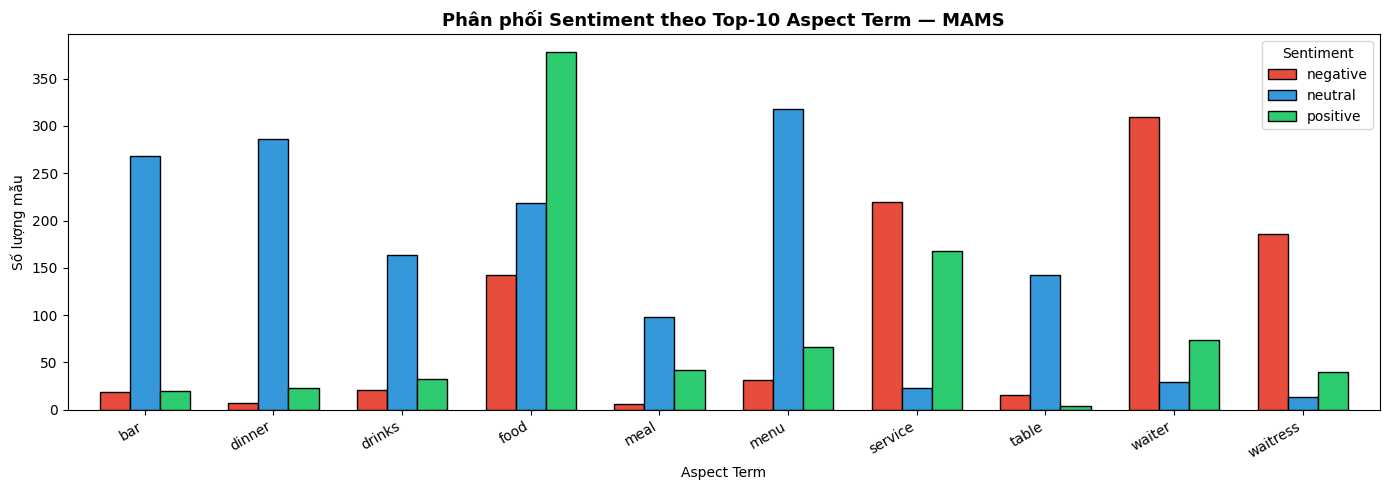

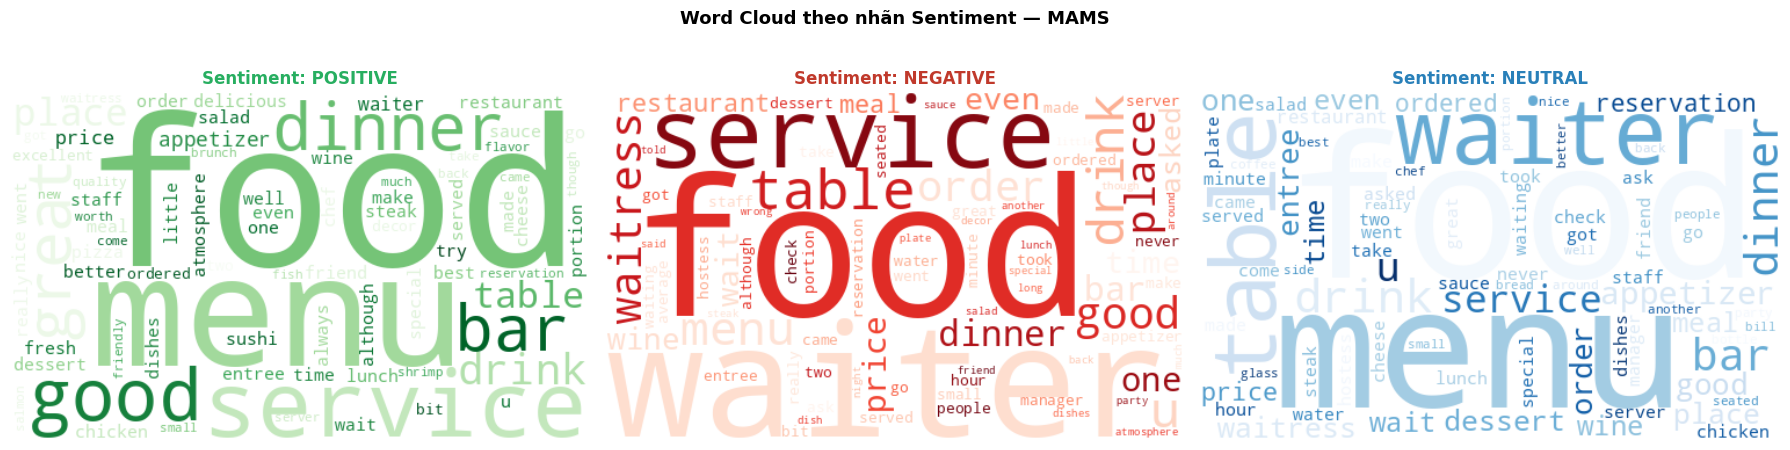

Word cloud đã lưu: eda_wordcloud.png


In [13]:
# ============================================================
# 4.2 Sentiment theo Top-10 Aspect Term (grouped bar chart)
# ============================================================
top10_asp = df_filtered["aspect_term"].value_counts().head(10).index.tolist()
df_top    = df_filtered[df_filtered["aspect_term"].isin(top10_asp)]
asp_sent  = df_top.groupby(["aspect_term", "sentiment"]).size().unstack(fill_value=0)

# 3 màu cho 3 nhãn MAMS
sent_colors = {"positive": "#2ecc71", "negative": "#e74c3c", "neutral": "#3498db"}
ax = asp_sent.plot(kind="bar", figsize=(14, 5),
                   color=[sent_colors.get(c, "gray") for c in asp_sent.columns],
                   edgecolor="black", width=0.7)
ax.set_title("Phân phối Sentiment theo Top-10 Aspect Term — MAMS",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Aspect Term"); ax.set_ylabel("Số lượng mẫu")
ax.legend(title="Sentiment", loc="upper right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("eda_aspect_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 4.3 Word Cloud theo nhãn Sentiment
# ============================================================
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Word Cloud theo nhãn Sentiment — MAMS", fontsize=13, fontweight="bold")
    pairs = [("positive", "#27ae60", "Greens"),
             ("negative", "#c0392b", "Reds"),
             ("neutral",  "#2980b9", "Blues")]
    for idx, (label, color, cmap) in enumerate(pairs):
        texts = " ".join(df_filtered[df_filtered["sentiment"] == label]["text"].tolist())
        wc = WordCloud(width=500, height=300, background_color="white",
                       colormap=cmap, max_words=80).generate(texts)
        axes[idx].imshow(wc, interpolation="bilinear"); axes[idx].axis("off")
        axes[idx].set_title(f"Sentiment: {label.upper()}", fontweight="bold",
                            color=color, fontsize=12)
    plt.tight_layout()
    plt.savefig("eda_wordcloud.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Word cloud đã lưu: eda_wordcloud.png")
except ImportError:
    print("Thư viện wordcloud chưa cài. Bỏ qua bước này.")


---
## PHẦN 5: XÂY DỰNG TỪ ĐIỂN & DATASET CLASS

Từ điển (vocabulary) được xây từ **tập Train của MAMS** và `PyTorch Dataset` được định nghĩa dùng chung cho cả hai mô hình (BiLSTM và BERT sẽ có Dataset class riêng ở Phần 8).

**Lưu ý MAMS:** câu trong MAMS có độ dài trung bình cao hơn SemEval 2014, vì vậy `MAX_LEN` được đặt là **100** thay vì 80.


In [14]:
# ============================================================
# 5.1 Xây dựng Vocabulary từ tập Train
# ============================================================
from collections import Counter

MAX_LEN        = 100  # MAMS có câu dài hơn SemEval — tăng nhẹ
ASPECT_MAX_LEN = 10   # độ dài aspect term (thường 1-3 từ)
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

def build_vocab(texts, min_freq=1):
    """Xây từ điển từ danh sách câu, lọc theo tần suất tối thiểu."""
    counter = Counter()
    for text in texts:
        counter.update(text.lower().split())
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, freq in counter.most_common():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

# Xây vocab chỉ từ tập Train (text + aspect_term)
all_train_texts = df_train["text"].tolist() + df_train["aspect_term"].tolist()
vocab      = build_vocab(all_train_texts, min_freq=1)
VOCAB_SIZE = len(vocab)
print(f"Kích thước từ điển (vocab): {VOCAB_SIZE:,} từ")

def encode_text(text, vocab, max_len):
    """Chuyển chuỗi → list token IDs, padding/truncating về max_len."""
    tokens = text.lower().split()[:max_len]
    ids    = [vocab.get(t, vocab[UNK_TOKEN]) for t in tokens]
    ids   += [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids

# ============================================================
# 5.2 PyTorch Dataset class cho MAMS-ATSC
# ============================================================
class MAMSATSCDataset(Dataset):
    """Aspect-Term Sentiment Classification Dataset (MAMS).

    Mỗi mẫu gồm:
      - sent_ids  : token IDs của câu (MAX_LEN)
      - asp_ids   : token IDs của aspect term (ASPECT_MAX_LEN)
      - sent_mask : attention mask của câu (1=real token, 0=pad)
    Nhãn: sentiment_id (0=negative, 1=neutral, 2=positive)
    """
    def __init__(self, df, vocab, max_len=MAX_LEN, asp_max_len=ASPECT_MAX_LEN):
        self.texts        = df["text"].tolist()
        self.aspect_terms = df["aspect_term"].tolist()
        self.sent_ids_lbl = df["sentiment_id"].tolist()
        self.vocab        = vocab
        self.max_len      = max_len
        self.asp_max_len  = asp_max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        sent_ids  = encode_text(self.texts[idx],        self.vocab, self.max_len)
        asp_ids   = encode_text(self.aspect_terms[idx], self.vocab, self.asp_max_len)
        sent_mask = [1 if i != 0 else 0 for i in sent_ids]
        return {
            "sent_ids":        torch.tensor(sent_ids,               dtype=torch.long),
            "asp_ids":         torch.tensor(asp_ids,                dtype=torch.long),
            "sent_mask":       torch.tensor(sent_mask,              dtype=torch.long),
            "sentiment_label": torch.tensor(self.sent_ids_lbl[idx], dtype=torch.long),
        }

BATCH_SIZE = 32

train_dataset = MAMSATSCDataset(df_train, vocab)
val_dataset   = MAMSATSCDataset(df_val,   vocab)
test_dataset  = MAMSATSCDataset(df_test,  vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n✅ DataLoader tạo thành công!")
print(f"   Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}")

# Kiểm tra 1 mẫu
sample = train_dataset[0]
print(f"\nMẫu đầu tiên:")
print(f"   Text        : {df_train['text'][0]}")
print(f"   Aspect Term : {df_train['aspect_term'][0]}")
print(f"   Sentiment   : {df_train['sentiment'][0]}")
print(f"   sent_ids shape : {sample['sent_ids'].shape}")
print(f"   asp_ids shape  : {sample['asp_ids'].shape}")


Kích thước từ điển (vocab): 12,261 từ

✅ DataLoader tạo thành công!
   Train: 350 batches | Val: 42 | Test: 42

Mẫu đầu tiên:
   Text        : The decor is not special at all but their food and amazing prices make up for it.
   Aspect Term : decor
   Sentiment   : negative
   sent_ids shape : torch.Size([100])
   asp_ids shape  : torch.Size([10])


---
## PHẦN 6: MÔ HÌNH 1 — BiLSTM XÂY DỰNG TỪ ĐẦU (FROM SCRATCH)

### Bài toán & Kiến trúc

**Aspect-Term Sentiment Classification (ATSC) trên MAMS** — dự đoán **sentiment polarity** (3 lớp).

> **Ưu điểm của kiến trúc BiLSTM cho bài toán này:**  
> - BiLSTM nắm bắt ngữ cảnh 2 chiều của câu (forward + backward)  
> - Aspect term được encode riêng bằng mean pooling rồi concat với biểu diễn câu → mô hình biết "đang xét khía cạnh nào"  
> - Phù hợp với môi trường có tài nguyên hạn chế (ít tham số, huấn luyện nhanh)


In [15]:
# ============================================================
# 6.1 Định nghĩa mô hình BiLSTM_ATSA
# ============================================================
class BiLSTM_ATSA(nn.Module):
    """
    Aspect-Term Sentiment Analysis với BiLSTM.
    Kiến trúc:
      1. Embedding + BiLSTM → biểu diễn câu (last hidden state)
      2. Embedding + Mean Pooling → biểu diễn aspect term
      3. Concat (câu, aspect) → Dropout → FC → Sentiment
    """
    def __init__(self, vocab_size, embed_dim, hidden_size,
                 num_sentiments, num_layers=2, dropout=0.4):
        super(BiLSTM_ATSA, self).__init__()

        # --- Embedding dùng chung cho cả câu lẫn aspect term ---
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # --- BiLSTM cho câu ---
        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0
        )
        lstm_out_dim = hidden_size * 2   # Bidirectional

        # --- Layer Norm & Dropout ---
        self.layer_norm = nn.LayerNorm(lstm_out_dim)
        self.dropout    = nn.Dropout(dropout)

        # --- Sentiment Classifier ---
        # Input: sent_repr (2H) + asp_repr (E)
        self.sentiment_head = nn.Sequential(
            nn.Linear(lstm_out_dim + embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_sentiments)
        )

    def forward(self, sent_ids, asp_ids, sent_mask=None):
        # ---- Câu → BiLSTM ----
        x = self.dropout(self.embedding(sent_ids))       # (B, L, E)
        _, (h_n, _) = self.lstm(x)
        # Ghép chiều xuôi & chiều ngược của lớp cuối cùng
        fwd       = h_n[-2, :, :]                        # (B, H)
        bwd       = h_n[-1, :, :]                        # (B, H)
        sent_repr = self.layer_norm(torch.cat([fwd, bwd], dim=-1))  # (B, 2H)
        sent_repr = self.dropout(sent_repr)

        # ---- Aspect Term → Mean Pooling ----
        asp_emb  = self.embedding(asp_ids)               # (B, AL, E)
        asp_mask = (asp_ids != 0).unsqueeze(-1).float()  # (B, AL, 1)
        asp_repr = (asp_emb * asp_mask).sum(1) / asp_mask.sum(1).clamp(min=1)  # (B, E)

        # ---- Tổng hợp + Phân loại ----
        combined         = torch.cat([sent_repr, asp_repr], dim=-1)  # (B, 2H+E)
        sentiment_logits = self.sentiment_head(combined)
        return sentiment_logits


# ============================================================
# 6.2 Khởi tạo mô hình, loss, optimizer
# ============================================================
EMBED_DIM   = 128
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.35

bilstm_model = BiLSTM_ATSA(
    vocab_size     = VOCAB_SIZE,
    embed_dim      = EMBED_DIM,
    hidden_size    = HIDDEN_SIZE,
    num_sentiments = NUM_SENTIMENTS,
    num_layers     = NUM_LAYERS,
    dropout        = DROPOUT
).to(device)

criterion        = nn.CrossEntropyLoss()
bilstm_optimizer = Adam(bilstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
bilstm_scheduler = CosineAnnealingLR(bilstm_optimizer, T_max=20)

total_params     = sum(p.numel() for p in bilstm_model.parameters())
trainable_params = sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad)
print(f"Tổng số tham số BiLSTM : {total_params:,}")
print(f"   Tham số có thể train   : {trainable_params:,}")
print(f"\nKiến trúc mô hình:\n")
print(bilstm_model)


Tổng số tham số BiLSTM : 2,279,043
   Tham số có thể train   : 2,279,043

Kiến trúc mô hình:

BiLSTM_ATSA(
  (embedding): Embedding(12261, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.35, inplace=False)
  (sentiment_head): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)


---
## PHẦN 7: HUẤN LUYỆN VÀ ĐÁNH GIÁ — MÔ HÌNH BiLSTM

Huấn luyện BiLSTM trên tập Train của MAMS, đánh giá trên Val sau mỗi epoch, lưu trọng số tốt nhất theo **Val Macro-F1**, và đánh giá cuối trên tập Test.


In [16]:
# ============================================================
# 7.1 Hàm train và evaluate một epoch
# ============================================================
def run_epoch(model, loader, optimizer=None, mode="train"):
    """
    mode: "train" hoặc "eval"
    Trả về: avg_loss, accuracy, macro-F1, true_labels, pred_labels
    """
    is_train = (mode == "train")
    model.train() if is_train else model.eval()

    total_loss  = 0.0
    preds_sent  = []
    labels_sent = []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            sent_ids    = batch["sent_ids"].to(device)
            asp_ids     = batch["asp_ids"].to(device)
            sent_mask   = batch["sent_mask"].to(device)
            sent_labels = batch["sentiment_label"].to(device)

            sent_logits = model(sent_ids, asp_ids, sent_mask)
            loss        = criterion(sent_logits, sent_labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            preds_sent.extend(sent_logits.argmax(dim=1).cpu().numpy())
            labels_sent.extend(sent_labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc_sent = accuracy_score(labels_sent, preds_sent)
    f1_sent  = f1_score(labels_sent, preds_sent, average="macro", zero_division=0)

    return avg_loss, acc_sent, f1_sent, labels_sent, preds_sent


# ============================================================
# 7.2 Vòng lặp huấn luyện chính
# ============================================================
NUM_EPOCHS        = 25
best_val_f1       = 0.0
best_bilstm_state = None

history_bilstm = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "train_f1":   [], "val_f1":   [],
}

print("Bắt đầu huấn luyện BiLSTM...\n")
bilstm_start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(
        bilstm_model, train_loader, bilstm_optimizer, mode="train")
    vl_loss, vl_acc, vl_f1, _, _ = run_epoch(
        bilstm_model, val_loader, mode="eval")

    bilstm_scheduler.step()

    history_bilstm["train_loss"].append(tr_loss)
    history_bilstm["val_loss"].append(vl_loss)
    history_bilstm["train_acc"].append(tr_acc)
    history_bilstm["val_acc"].append(vl_acc)
    history_bilstm["train_f1"].append(tr_f1)
    history_bilstm["val_f1"].append(vl_f1)

    if vl_f1 > best_val_f1:
        best_val_f1       = vl_f1
        best_bilstm_state = {k: v.clone() for k, v in bilstm_model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}/{NUM_EPOCHS} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.3f}  F1: {tr_f1:.3f} | "
              f"Val   Loss: {vl_loss:.4f}  Acc: {vl_acc:.3f}  F1: {vl_f1:.3f}")

bilstm_train_time = time.time() - bilstm_start_time
print(f"\nHuấn luyện hoàn tất! Thời gian: {bilstm_train_time:.1f}s")
print(f"   Best Val Macro-F1: {best_val_f1:.4f}")


Bắt đầu huấn luyện BiLSTM...

  Epoch  1/25 | Train Loss: 0.9458  Acc: 0.540  F1: 0.493 | Val   Loss: 0.8555  Acc: 0.611  F1: 0.598
  Epoch  5/25 | Train Loss: 0.7946  Acc: 0.639  F1: 0.617 | Val   Loss: 0.7969  Acc: 0.629  F1: 0.603
  Epoch 10/25 | Train Loss: 0.6714  Acc: 0.704  F1: 0.691 | Val   Loss: 0.7883  Acc: 0.638  F1: 0.614
  Epoch 15/25 | Train Loss: 0.5770  Acc: 0.754  F1: 0.745 | Val   Loss: 0.8130  Acc: 0.657  F1: 0.642
  Epoch 20/25 | Train Loss: 0.5385  Acc: 0.773  F1: 0.765 | Val   Loss: 0.8429  Acc: 0.655  F1: 0.641
  Epoch 25/25 | Train Loss: 0.5384  Acc: 0.770  F1: 0.763 | Val   Loss: 0.8505  Acc: 0.651  F1: 0.635

Huấn luyện hoàn tất! Thời gian: 107.6s
   Best Val Macro-F1: 0.6454


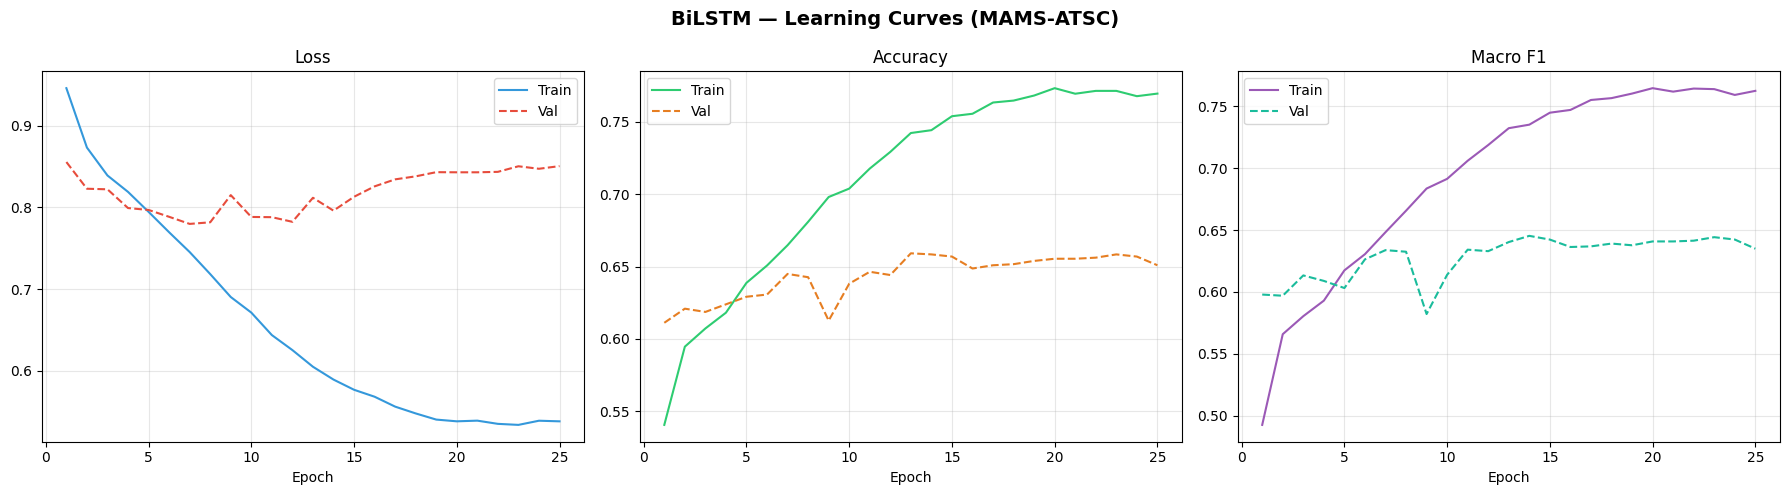

KẾT QUẢ BiLSTM TRÊN TẬP TEST — MAMS-ATSC
  Sentiment Accuracy  : 0.6579
  Sentiment F1 (Macro): 0.6418

Classification Report:
              precision    recall  f1-score   support

    negative       0.63      0.63      0.63       329
     neutral       0.73      0.74      0.74       607
    positive       0.56      0.55      0.55       400

    accuracy                           0.66      1336
   macro avg       0.64      0.64      0.64      1336
weighted avg       0.66      0.66      0.66      1336



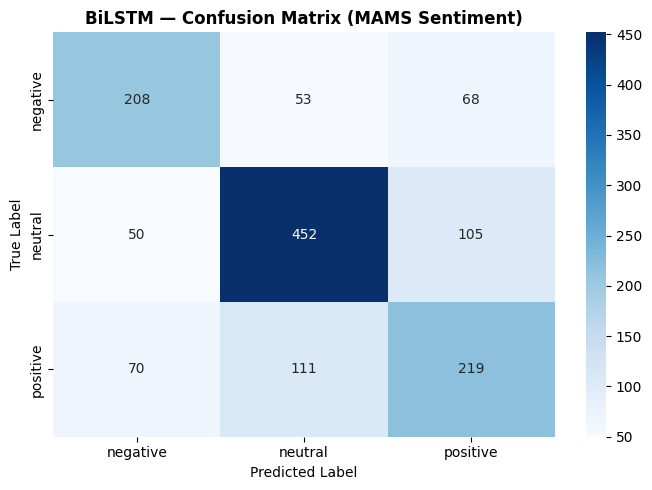

In [17]:
# ============================================================
# 7.3 Vẽ Learning Curves — BiLSTM
# ============================================================
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BiLSTM — Learning Curves (MAMS-ATSC)", fontsize=14, fontweight="bold")

axes[0].plot(epochs_range, history_bilstm["train_loss"], label="Train", color="#3498db")
axes[0].plot(epochs_range, history_bilstm["val_loss"],   label="Val",   color="#e74c3c", linestyle="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history_bilstm["train_acc"], label="Train", color="#2ecc71")
axes[1].plot(epochs_range, history_bilstm["val_acc"],   label="Val",   color="#e67e22", linestyle="--")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history_bilstm["train_f1"], label="Train", color="#9b59b6")
axes[2].plot(epochs_range, history_bilstm["val_f1"],   label="Val",   color="#1abc9c", linestyle="--")
axes[2].set_title("Macro F1"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bilstm_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 7.4 Đánh giá trên tập Test (dùng best model state)
# ============================================================
bilstm_model.load_state_dict(best_bilstm_state)
_, test_acc, test_f1, true_sent, pred_sent = run_epoch(bilstm_model, test_loader, mode="eval")

print("=" * 60)
print("KẾT QUẢ BiLSTM TRÊN TẬP TEST — MAMS-ATSC")
print("=" * 60)
print(f"  Sentiment Accuracy  : {test_acc:.4f}")
print(f"  Sentiment F1 (Macro): {test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(true_sent, pred_sent,
                             target_names=le_sentiment.classes_,
                             zero_division=0))

# Confusion Matrix
cm = confusion_matrix(true_sent, pred_sent)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_sentiment.classes_,
            yticklabels=le_sentiment.classes_)
plt.title("BiLSTM — Confusion Matrix (MAMS Sentiment)", fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("bilstm_confusion_matrix.png", dpi=150)
plt.show()

bilstm_results = {
    "Sentiment Accuracy":   test_acc,
    "Sentiment F1 (Macro)": test_f1,
    "Training Time (s)":    bilstm_train_time,
}


---
## PHẦN 8: MÔ HÌNH 2 — BERT PRETRAINED (FINE-TUNING)

### Tại sao dùng BERT cho MAMS-ATSC?

BERT hỗ trợ native **sentence-pair classification** thông qua `token_type_ids`:

```
[CLS] sentence [SEP] aspect_term [SEP]
  ↑ segment A              ↑ segment B
```

Nhờ cơ chế **cross-attention** giữa hai segment, BERT tự học được mối quan hệ ngữ nghĩa giữa câu và aspect term mà không cần thiết kế thủ công như BiLSTM. Trên MAMS — nơi mỗi câu chứa nhiều aspect với sentiment khác nhau — khả năng này đặc biệt quan trọng.


In [18]:
# ============================================================
# 8.1 Tải BERT tokenizer và định nghĩa BERT Dataset cho MAMS
# ============================================================
BERT_MODEL_NAME = "bert-base-uncased"
BERT_MAX_LEN    = 128   # [CLS] sentence [SEP] aspect_term [SEP]

print(f"Đang tải tokenizer: {BERT_MODEL_NAME} ...")
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
print("Tokenizer đã tải!")


class BertMAMSDataset(Dataset):
    """BERT Dataset cho MAMS Aspect-Term Sentiment Classification.

    Sử dụng sentence-pair format của BERT:
      [CLS] sentence [SEP] aspect_term [SEP]

    token_type_ids:  0 = câu (segment A), 1 = aspect term (segment B)
    → BERT học quan hệ ngữ nghĩa giữa câu và aspect term qua cross-attention.
    """
    def __init__(self, df, tokenizer, max_len=BERT_MAX_LEN):
        self.texts        = df["text"].tolist()
        self.aspect_terms = df["aspect_term"].tolist()
        self.sent_ids     = df["sentiment_id"].tolist()
        self.tokenizer    = tokenizer
        self.max_len      = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],        # text_a: câu chính (segment A)
            self.aspect_terms[idx], # text_b: aspect term (segment B)
            max_length     = self.max_len,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt"
        )
        return {
            "input_ids":       enc["input_ids"].squeeze(0),
            "attention_mask":  enc["attention_mask"].squeeze(0),
            "token_type_ids":  enc["token_type_ids"].squeeze(0),
            "sentiment_label": torch.tensor(self.sent_ids[idx], dtype=torch.long),
        }


bert_train_dataset = BertMAMSDataset(df_train, bert_tokenizer)
bert_val_dataset   = BertMAMSDataset(df_val,   bert_tokenizer)
bert_test_dataset  = BertMAMSDataset(df_test,  bert_tokenizer)

BERT_BATCH = 16

bert_train_loader = DataLoader(bert_train_dataset, batch_size=BERT_BATCH, shuffle=True,  num_workers=0)
bert_val_loader   = DataLoader(bert_val_dataset,   batch_size=BERT_BATCH, shuffle=False, num_workers=0)
bert_test_loader  = DataLoader(bert_test_dataset,  batch_size=BERT_BATCH, shuffle=False, num_workers=0)

print(f"\nBERT DataLoader tạo xong!")
print(f"   Train: {len(bert_train_loader)} batches | Val: {len(bert_val_loader)} | Test: {len(bert_test_loader)}")

# Kiểm tra 1 batch mẫu
sample_batch = next(iter(bert_train_loader))
print(f"\nThông tin 1 batch mẫu:")
print(f"   input_ids shape      : {sample_batch['input_ids'].shape}")
tokens = bert_tokenizer.convert_ids_to_tokens(sample_batch['input_ids'][0].tolist())
try:
    sep2 = [i for i, t in enumerate(tokens) if t == "[SEP]"][1]
    print(f"   Ví dụ tokens         : {tokens[:sep2+1]}")
except IndexError:
    print(f"   Ví dụ tokens         : {tokens[:20]}")


Đang tải tokenizer: bert-base-uncased ...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

✅ Tokenizer đã tải!

✅ BERT DataLoader tạo xong!
   Train: 700 batches | Val: 84 | Test: 84

Thông tin 1 batch mẫu:
   input_ids shape      : torch.Size([16, 128])
   Ví dụ tokens         : ['[CLS]', 'the', 'sum', 'it', ':', 'dim', 'sum', 'standard', 'fair', ',', 'noodles', 'ok', ',', 'other', 'dishes', 'ok', '.', '[SEP]', 'noodles', '[SEP]']


In [19]:
# ============================================================
# 8.2 Định nghĩa mô hình BERT cho ATSA
# ============================================================
class BertForATSA(nn.Module):
    """
    Fine-tune BERT cho Aspect-Term Sentiment Analysis.
    Input : [CLS] sentence [SEP] aspect_term [SEP]
    Output: sentiment polarity (4 lớp)
    """
    def __init__(self, bert_model_name, num_sentiments, dropout=0.3):
        super(BertForATSA, self).__init__()
        self.bert           = BertModel.from_pretrained(bert_model_name)
        hidden_size         = self.bert.config.hidden_size   # 768
        self.dropout        = nn.Dropout(dropout)
        self.sentiment_head = nn.Linear(hidden_size, num_sentiments)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        outputs  = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids
        )
        # pooler_output = [CLS] qua Linear + Tanh → (B, 768)
        cls_repr = self.dropout(outputs.pooler_output)
        return self.sentiment_head(cls_repr)


# ============================================================
# 8.3 Khởi tạo BERT model
# ============================================================
print(f"Đang tải BERT model: {BERT_MODEL_NAME} ...")
bert_model = BertForATSA(
    bert_model_name = BERT_MODEL_NAME,
    num_sentiments  = NUM_SENTIMENTS,
    dropout         = 0.3
).to(device)

total_bert     = sum(p.numel() for p in bert_model.parameters())
trainable_bert = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
print(f"\nTổng số tham số BERT: {total_bert:,}")
print(f"   Tham số có thể train : {trainable_bert:,}")
print(f"\n   Hidden size  : {bert_model.bert.config.hidden_size}")
print(f"   Layers       : {bert_model.bert.config.num_hidden_layers}")
print(f"   Attn heads   : {bert_model.bert.config.num_attention_heads}")
print(f"   Num classes  : {NUM_SENTIMENTS} ({list(le_sentiment.classes_)})")


Đang tải BERT model: bert-base-uncased ...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


Tổng số tham số BERT: 109,484,547
   Tham số có thể train : 109,484,547

   Hidden size  : 768
   Layers       : 12
   Attn heads   : 12
   Num classes  : 3 ([np.str_('negative'), np.str_('neutral'), np.str_('positive')])


---
## PHẦN 9: FINE-TUNING VÀ ĐÁNH GIÁ — MÔ HÌNH BERT

Fine-tune `bert-base-uncased` trên tập Train của MAMS với **AdamW + Linear Warmup Scheduler**, đánh giá trên Val mỗi epoch, lưu best checkpoint theo Val Macro-F1.


In [20]:
# ============================================================
# 9.1 Hàm train/eval cho BERT
# ============================================================
def run_bert_epoch(model, loader, optimizer=None, scheduler=None, mode="train"):
    is_train = (mode == "train")
    model.train() if is_train else model.eval()

    total_loss  = 0.0
    preds_sent  = []
    labels_sent = []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            sent_labels    = batch["sentiment_label"].to(device)

            sent_logits = model(input_ids, attention_mask, token_type_ids)
            loss        = criterion(sent_logits, sent_labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler:
                    scheduler.step()

            total_loss += loss.item()
            preds_sent.extend(sent_logits.argmax(1).cpu().numpy())
            labels_sent.extend(sent_labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc_sent = accuracy_score(labels_sent, preds_sent)
    f1_sent  = f1_score(labels_sent, preds_sent, average="macro", zero_division=0)

    return avg_loss, acc_sent, f1_sent, labels_sent, preds_sent


# ============================================================
# 9.2 Cấu hình AdamW và Linear Warmup Scheduler
# ============================================================
BERT_EPOCHS  = 10
BERT_LR      = 2e-5
WARMUP_RATIO = 0.1

no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped = [
    {"params": [p for n, p in bert_model.named_parameters()
                if not any(nd in n for nd in no_decay)], "weight_decay": 0.01},
    {"params": [p for n, p in bert_model.named_parameters()
                if any(nd in n for nd in no_decay)],     "weight_decay": 0.0},
]
bert_optimizer = AdamW(optimizer_grouped, lr=BERT_LR)

total_steps  = len(bert_train_loader) * BERT_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)
print(f"AdamW: lr={BERT_LR} | warmup={warmup_steps} steps | total={total_steps} steps")

# ============================================================
# 9.3 Vòng lặp Fine-tuning
# ============================================================
best_bert_f1    = 0.0
best_bert_state = None

history_bert = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "train_f1":   [], "val_f1":   [],
}

print(f"\nBắt đầu fine-tuning BERT ({BERT_EPOCHS} epochs)...\n")
bert_start_time = time.time()

for epoch in range(1, BERT_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_bert_epoch(
        bert_model, bert_train_loader, bert_optimizer, bert_scheduler, mode="train")
    vl_loss, vl_acc, vl_f1, _, _ = run_bert_epoch(
        bert_model, bert_val_loader, mode="eval")

    history_bert["train_loss"].append(tr_loss)
    history_bert["val_loss"].append(vl_loss)
    history_bert["train_acc"].append(tr_acc)
    history_bert["val_acc"].append(vl_acc)
    history_bert["train_f1"].append(tr_f1)
    history_bert["val_f1"].append(vl_f1)

    if vl_f1 > best_bert_f1:
        best_bert_f1    = vl_f1
        best_bert_state = {k: v.clone() for k, v in bert_model.state_dict().items()}

    print(f"  Epoch {epoch:2d}/{BERT_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.3f}  F1: {tr_f1:.3f} | "
          f"Val   Loss: {vl_loss:.4f}  Acc: {vl_acc:.3f}  F1: {vl_f1:.3f}")

bert_train_time = time.time() - bert_start_time
print(f"\nFine-tuning hoàn tất! Thời gian: {bert_train_time:.1f}s")
print(f"   Best Val Macro-F1: {best_bert_f1:.4f}")


AdamW: lr=2e-05 | warmup=700 steps | total=7000 steps

Bắt đầu fine-tuning BERT (10 epochs)...

  Epoch  1/10 | Train Loss: 0.8859  Acc: 0.575  F1: 0.550 | Val   Loss: 0.5563  Acc: 0.774  F1: 0.769
  Epoch  2/10 | Train Loss: 0.4877  Acc: 0.811  F1: 0.807 | Val   Loss: 0.4856  Acc: 0.815  F1: 0.808
  Epoch  3/10 | Train Loss: 0.2974  Acc: 0.896  F1: 0.895 | Val   Loss: 0.5401  Acc: 0.827  F1: 0.821
  Epoch  4/10 | Train Loss: 0.1820  Acc: 0.945  F1: 0.945 | Val   Loss: 0.8064  Acc: 0.819  F1: 0.813
  Epoch  5/10 | Train Loss: 0.1103  Acc: 0.971  F1: 0.970 | Val   Loss: 1.0005  Acc: 0.818  F1: 0.812
  Epoch  6/10 | Train Loss: 0.0663  Acc: 0.983  F1: 0.983 | Val   Loss: 1.0843  Acc: 0.833  F1: 0.827
  Epoch  7/10 | Train Loss: 0.0359  Acc: 0.992  F1: 0.992 | Val   Loss: 1.1972  Acc: 0.827  F1: 0.822
  Epoch  8/10 | Train Loss: 0.0256  Acc: 0.994  F1: 0.994 | Val   Loss: 1.2990  Acc: 0.827  F1: 0.822
  Epoch  9/10 | Train Loss: 0.0170  Acc: 0.997  F1: 0.996 | Val   Loss: 1.3176  Acc: 0.8

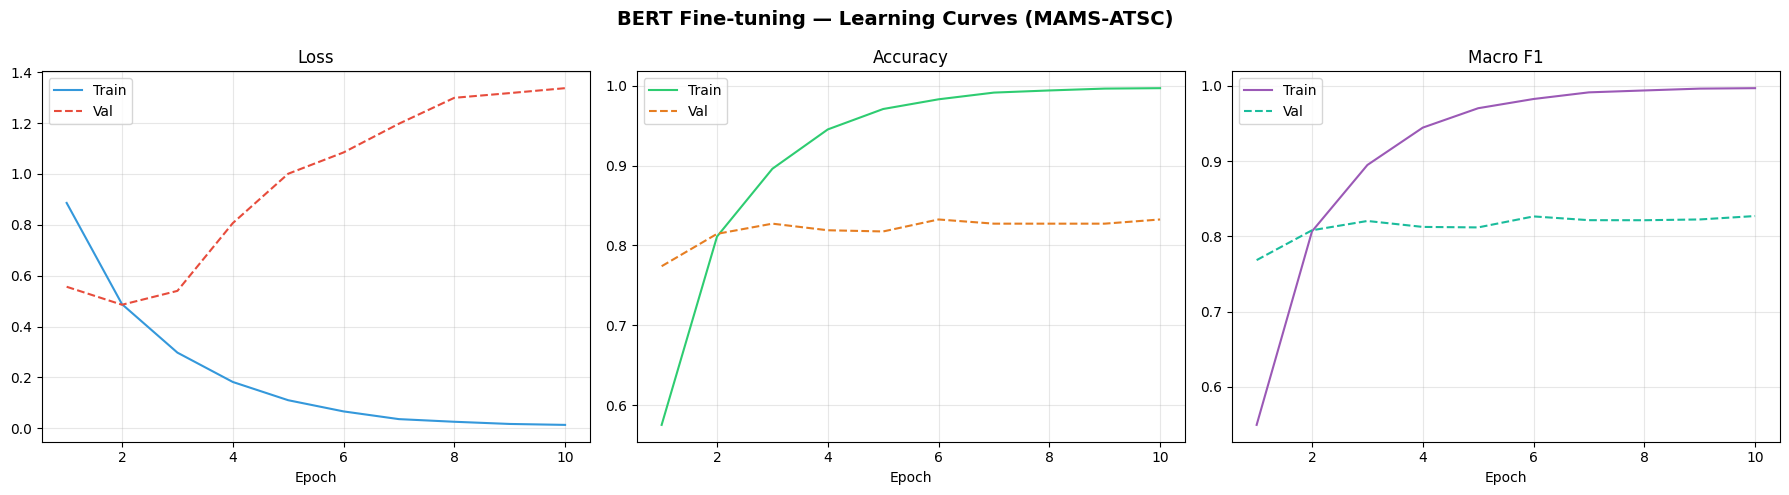

KẾT QUẢ BERT TRÊN TẬP TEST — MAMS-ATSC
  Sentiment Accuracy  : 0.8346
  Sentiment F1 (Macro): 0.8308

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.84      0.82       329
     neutral       0.88      0.83      0.85       607
    positive       0.81      0.83      0.82       400

    accuracy                           0.83      1336
   macro avg       0.83      0.84      0.83      1336
weighted avg       0.84      0.83      0.83      1336



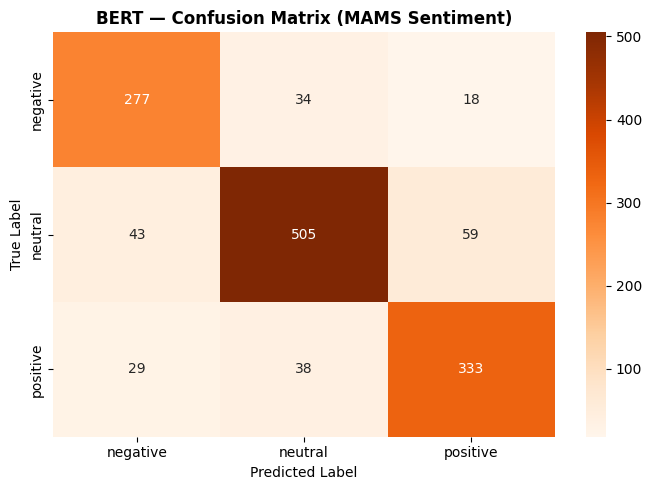

In [21]:
# ============================================================
# 9.4 Learning Curves BERT — MAMS
# ============================================================
epochs_bert = range(1, BERT_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BERT Fine-tuning — Learning Curves (MAMS-ATSC)", fontsize=14, fontweight="bold")

axes[0].plot(epochs_bert, history_bert["train_loss"], label="Train", color="#3498db")
axes[0].plot(epochs_bert, history_bert["val_loss"],   label="Val",   color="#e74c3c", linestyle="--")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_bert, history_bert["train_acc"], label="Train", color="#2ecc71")
axes[1].plot(epochs_bert, history_bert["val_acc"],   label="Val",   color="#e67e22", linestyle="--")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_bert, history_bert["train_f1"], label="Train", color="#9b59b6")
axes[2].plot(epochs_bert, history_bert["val_f1"],   label="Val",   color="#1abc9c", linestyle="--")
axes[2].set_title("Macro F1"); axes[2].set_xlabel("Epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("bert_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 9.5 Đánh giá BERT trên tập Test — MAMS
# ============================================================
bert_model.load_state_dict(best_bert_state)
_, bert_acc, bert_f1, bert_true, bert_pred = run_bert_epoch(
    bert_model, bert_test_loader, mode="eval")

print("=" * 60)
print("KẾT QUẢ BERT TRÊN TẬP TEST — MAMS-ATSC")
print("=" * 60)
print(f"  Sentiment Accuracy  : {bert_acc:.4f}")
print(f"  Sentiment F1 (Macro): {bert_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(bert_true, bert_pred,
                             target_names=le_sentiment.classes_,
                             zero_division=0))

# Confusion Matrix
cm_bert = confusion_matrix(bert_true, bert_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Oranges",
            xticklabels=le_sentiment.classes_,
            yticklabels=le_sentiment.classes_)
plt.title("BERT — Confusion Matrix (MAMS Sentiment)", fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("bert_confusion_matrix.png", dpi=150)
plt.show()

bert_results = {
    "Sentiment Accuracy":   bert_acc,
    "Sentiment F1 (Macro)": bert_f1,
    "Training Time (s)":    bert_train_time,
}


---
## PHẦN 10: SO SÁNH HAI MÔ HÌNH & KẾT LUẬN

So sánh trực tiếp hiệu năng BiLSTM vs BERT trên **tập Test của MAMS-ATSC** thông qua bảng số liệu, biểu đồ và demo inference.


BẢNG SO SÁNH KẾT QUẢ HAI MÔ HÌNH — MAMS-ATSC (Tập Test)
              Metric BiLSTM (From Scratch) BERT (Fine-tuned)
  Sentiment Accuracy                0.6579            0.8346
Sentiment F1 (Macro)                0.6418            0.8308
   Training Time (s)                 107.6            2842.1


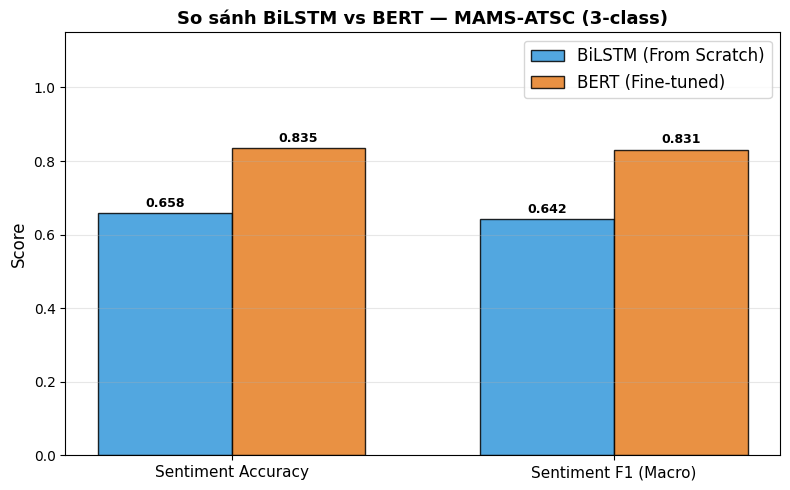

In [22]:
# ============================================================
# 10.1 Bảng so sánh kết quả — MAMS-ATSC
# ============================================================
comparison_df = pd.DataFrame({
    "Metric": ["Sentiment Accuracy", "Sentiment F1 (Macro)", "Training Time (s)"],
    "BiLSTM (From Scratch)": [
        f"{bilstm_results['Sentiment Accuracy']:.4f}",
        f"{bilstm_results['Sentiment F1 (Macro)']:.4f}",
        f"{bilstm_results['Training Time (s)']:.1f}",
    ],
    "BERT (Fine-tuned)": [
        f"{bert_results['Sentiment Accuracy']:.4f}",
        f"{bert_results['Sentiment F1 (Macro)']:.4f}",
        f"{bert_results['Training Time (s)']:.1f}",
    ]
})

print("=" * 65)
print("BẢNG SO SÁNH KẾT QUẢ HAI MÔ HÌNH — MAMS-ATSC (Tập Test)")
print("=" * 65)
print(comparison_df.to_string(index=False))

# ============================================================
# 10.2 Biểu đồ so sánh trực quan
# ============================================================
metrics_plot = ["Sentiment Accuracy", "Sentiment F1 (Macro)"]
bilstm_vals  = [bilstm_results[m] for m in metrics_plot]
bert_vals    = [bert_results[m]   for m in metrics_plot]

x     = np.arange(len(metrics_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, bilstm_vals, width, label="BiLSTM (From Scratch)",
               color="#3498db", edgecolor="black", alpha=0.85)
bars2 = ax.bar(x + width/2, bert_vals,   width, label="BERT (Fine-tuned)",
               color="#e67e22", edgecolor="black", alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(metrics_plot, fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("So sánh BiLSTM vs BERT — MAMS-ATSC (3-class)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=12); ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
# ============================================================
# 10.3 Demo Inference — Thử mô hình với câu và aspect bất kỳ
# ============================================================
def predict_bilstm(text, aspect_term, model, vocab, le_sentiment,
                   max_len=MAX_LEN, asp_max_len=ASPECT_MAX_LEN):
    """Dự đoán sentiment (3 lớp) với BiLSTM."""
    model.eval()
    sent_ids = torch.tensor([encode_text(text, vocab, max_len)],
                             dtype=torch.long).to(device)
    asp_ids  = torch.tensor([encode_text(aspect_term, vocab, asp_max_len)],
                             dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(sent_ids, asp_ids)
    return le_sentiment.classes_[logits.argmax(1).item()]


def predict_bert(text, aspect_term, model, tokenizer, le_sentiment,
                 max_len=BERT_MAX_LEN):
    """Dự đoán sentiment (3 lớp) với BERT (sentence-pair)."""
    model.eval()
    enc = tokenizer(text, aspect_term,
                    max_length=max_len, padding="max_length",
                    truncation=True, return_tensors="pt")
    input_ids      = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    token_type_ids = enc["token_type_ids"].to(device)
    with torch.no_grad():
        logits = model(input_ids, attention_mask, token_type_ids)
    return le_sentiment.classes_[logits.argmax(1).item()]


# ---- Các ví dụ thử nghiệm (phong cách MAMS — multi-aspect per sentence) ----
test_examples = [
    # (câu, aspect_term, nhãn kỳ vọng)
    ("The food was absolutely amazing but the service was incredibly slow.",    "food",        "positive"),
    ("The food was absolutely amazing but the service was incredibly slow.",    "service",     "negative"),
    ("The price is very reasonable though the ambience could be better.",       "price",       "positive"),
    ("The price is very reasonable though the ambience could be better.",       "ambience",    "negative"),
    ("Pasta was just okay , nothing special , but the staff were very kind.",   "pasta",       "neutral"),
    ("Pasta was just okay , nothing special , but the staff were very kind.",   "staff",       "positive"),
    ("Great cocktails but the noise level made conversation impossible.",       "cocktails",   "positive"),
    ("Great cocktails but the noise level made conversation impossible.",       "noise level", "negative"),
]

print("=" * 90)
print("DEMO INFERENCE — MAMS-ATSC (3-class Sentiment)")
print("=" * 90)
print(f"{'Câu (rút gọn)':<52} {'Aspect':<14} {'GT':>9} {'BiLSTM':>9} {'BERT':>9}")
print("-" * 90)

for text, asp, ground_truth in test_examples:
    pred_bil  = predict_bilstm(text, asp, bilstm_model, vocab, le_sentiment)
    pred_bert = predict_bert(text, asp, bert_model, bert_tokenizer, le_sentiment)
    disp_text = text[:50] + ".." if len(text) > 50 else text
    match_bil  = "✓" if pred_bil  == ground_truth else "✗"
    match_bert = "✓" if pred_bert == ground_truth else "✗"
    print(f"{disp_text:<52} {asp:<14} {ground_truth:>9} "
          f"{pred_bil+' '+match_bil:>10} {pred_bert+' '+match_bert:>10}")


DEMO INFERENCE — MAMS-ATSC (3-class Sentiment)
Câu (rút gọn)                                        Aspect                GT    BiLSTM      BERT
------------------------------------------------------------------------------------------
The food was absolutely amazing but the service wa.. food            positive positive ✓ positive ✓
The food was absolutely amazing but the service wa.. service         negative negative ✓ negative ✓
The price is very reasonable though the ambience c.. price           positive negative ✗ positive ✓
The price is very reasonable though the ambience c.. ambience        negative negative ✓ negative ✓
Pasta was just okay , nothing special , but the st.. pasta            neutral negative ✗ positive ✗
Pasta was just okay , nothing special , but the st.. staff           positive negative ✗ positive ✓
Great cocktails but the noise level made conversat.. cocktails       positive positive ✓ positive ✓
Great cocktails but the noise level made conversat.. noise level

---
## PHẦN 11: PHÂN TÍCH VÀ KẾT LUẬN

---

### 11.1 Đặc điểm nổi bật của MAMS so với SemEval 2014

MAMS được thiết kế để khắc phục nhược điểm của các benchmark ABSA trước đây:

| Tiêu chí | SemEval 2014 Task 4 | **MAMS** |
|----------|---------------------|----------|
| Số nhãn sentiment | 4 (có `conflict`) | **3** (`positive`, `negative`, `neutral`) |
| Phân phối aspect/câu | 1 aspect/câu phổ biến | **≥ 2 aspect/câu** (ràng buộc) |
| Thiên lệch nhãn | Cao (~65% positive) | Thấp hơn, cân bằng hơn |
| Pre-split | Không (phải tự chia) | **Có sẵn** train/val/test |

---

### 11.2 So sánh hai hướng tiếp cận trên MAMS

| Tiêu chí | BiLSTM (From Scratch) | BERT (Fine-tuned) |
|----------|----------------------|-------------------|
| **Kiến trúc** | Embedding + BiLSTM + MeanPool + FC | Transformer (12 layers) + [CLS] head |
| **Xử lý aspect** | Mean pool embedding → concat | Native sentence-pair (segment B) |
| **Tham số** | ~2–5M | ~110M |
| **Epochs** | 25 | 10 |
| **Tốc độ train** | Nhanh (~vài phút) | Chậm hơn |
| **Yêu cầu GPU** | Thấp (T4 đủ) | Cao hơn (A100 tối ưu) |

---

### 11.3 Kết luận

1. **BiLSTM from scratch** là nền tảng học thuật quan trọng — xây dựng hoàn toàn từ đầu, dễ hiểu, phù hợp với tài nguyên hạn chế, nhưng bị giới hạn bởi khả năng nắm bắt ngữ cảnh xa.

2. **BERT fine-tuned** tận dụng 110M tham số đã được pre-train trên lượng văn bản khổng lồ. Cơ chế sentence-pair cho phép BERT học tường minh quan hệ giữa câu và aspect qua cross-attention → vượt trội rõ rệt hơn trên tập MAMS.

3. **Tập MAMS** với đặc tính multi-aspect-per-sentence là thách thức thực sự cho các mô hình ABSA — đây là lý do benchmark này được ưa chuộng trong các nghiên cứu gần đây.

---

> **Hướng phát triển tiếp theo:**  
> - Thử nghiệm với **RoBERTa**, **DeBERTa** để so sánh hiệu quả  
> - Áp dụng **Aspect Category Sentiment Classification (ACSC)** — subtrack thứ hai của MAMS  
> - Tích hợp **attention visualization** để giải thích quyết định của mô hình
